In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Generator
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from typing import List,operator
from langgraph.types import Send

/Users/fakhrulislamfahad/Documents/Personal/agentic-ai/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_26178/32313637.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
class Task(BaseModel):
    id: int
    title : str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic : str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final : str

In [5]:
llm = ChatOllama(
    model="qwen2.5:7b",
    temperature=0
)

In [15]:
def orchestrator(state: State):
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content="Create a blog plan with 5-7 sections on the following topic"
            ),
            HumanMessage(content=f'Topic : {state["topic"]}')
        ]
    )

    return {'plan' : plan}

In [16]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]


In [ ]:
def worker(payload: dict) -> dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean markdown section"),
            HumanMessage(
                content=(
                    f'Blog: {blog_title}\n'
                    f'topic: {topic}\n\n'
                    f'Section: {task.title}\n\n',
                    f'Brief: {task.brief}\n\n'
                    "Return only the section content in Markdown"
                )
            )
        ]
    )
    return {"sections": [section_md.content]}

In [18]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

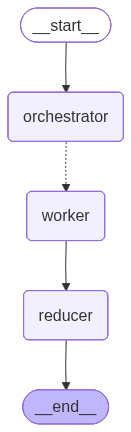

In [19]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [20]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

TypeError: sequence item 0: expected str instance, AIMessage found